# Regressão Linear
#### Preditando a popularidade de um filme com base no ano de lançamento, nota média e contagem de votos
#### Integrantes
- Gabriel Almeida Mota Bomfim
- Pedro Caldas de Souze Lucas Marques
- Carlos Henrico Fontes Cabral
#### Fonte dos dados:
- https://www.kaggle.com/datasets/siddharthbhakta/tmdb-top-10000-movies-updated-2026
#### Objetivo
Preditar a popularidade do filme
#### Atributo-Alvo
- Feature popularity
#### Atributos preditivos
- Ano
- vote_average
- vote_count

# Compressão dos dados

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url_dados = "https://raw.githubusercontent.com/gabrielamb2k/FundamentosIA/main/moviesTMBD.csv"

movies = pd.read_csv(url_dados)
movies.head()

,Unnamed: 0,id,title,popularity,adult,original_language,overview,release_date,vote_average,vote_count
0,0,1007757,Swapped,327.5134,False,en,"A small woodland creature and a majestic bird,...",2026-05-01,8.987,1320
1,1,278,The Shawshank Redemption,65.3308,False,en,Imprisoned in the 1940s for the double murder ...,1994-09-23,8.721,30387
2,2,238,The Godfather,47.2346,False,en,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,8.686,22929
3,3,687163,Project Hail Mary,422.0199,False,en,Science teacher Ryland Grace wakes up on a spa...,2026-03-15,8.621,3950
4,4,240,The Godfather Part II,27.6763,False,en,In the continuing saga of the Corleone crime f...,1974-12-20,8.571,13901


#### Verificando dados ausentes e duplicações
- Procurando nas colunas do dataset com valores reais em busca de valores NaN

In [ ]:
movies.info()

print('-----------------------------')
print('Verificando valores NaN')
print(movies.isna().sum())

qtd_titulos_duplicados = movies.duplicated(subset=['title']).sum()
qtd_overview_duplicadas = movies.duplicated(subset=['overview']).sum()

print("-----------------------------")
print("Verificando duplicações")
print(f"Títulos duplicados: {qtd_titulos_duplicados}")
print(f"Overview duplicadas: {qtd_overview_duplicadas}")

<class 'pandas.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9980 non-null   int64  
 1   id                 9980 non-null   int64  
 2   title              9980 non-null   str    
 3   popularity         9980 non-null   float64
 4   adult              9980 non-null   bool   
 5   original_language  9980 non-null   str    
 6   overview           9978 non-null   str    
 7   release_date       9978 non-null   str    
 8   vote_average       9980 non-null   float64
 9   vote_count         9980 non-null   int64  
dtypes: bool(1), float64(2), int64(3), str(4)
memory usage: 711.6 KB
-----------------------------
Verificando valores NaN
Unnamed: 0           0
id                   0
title                0
popularity           0
adult                0
original_language    0
overview             2
release_date         2
vote_average         

**Interpretação da Compreensão dos Dados:**
* **Estrutura:** O conjunto de dados possui 9980 registros iniciais e 10 atributos.
* **Valores Ausentes e Inconsistências:** Encontramos apenas 2 valores nulos nas colunas `overview` e `release_date`.
* **Duplicações:** A base apresenta 875 títulos duplicados e 564 descrições (overviews) duplicadas, o que indica que filmes foram raspados mais de uma vez ou regravados com o mesmo nome.
* **Tipos de Variáveis:** Temos variáveis numéricas contínuas (popularity, vote_average), numéricas discretas (vote_count), booleanas (adult) e categóricas/textuais (title, original_language, overview).

**Distribuição do Atributo-Alvo (Popularity):**
Abaixo, analisamos a distribuição da variável que queremos predizer.

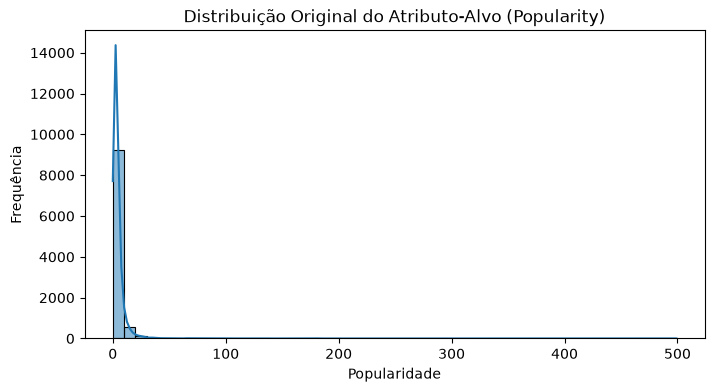

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(movies['popularity'], bins=50, kde=True)
plt.title('Distribuição Original do Atributo-Alvo (Popularity)')
plt.xlabel('Popularidade')
plt.ylabel('Frequência')
plt.show()

**Justificativa do Pré-processamento:**
1. **Remoção de Duplicatas e Valores Nulos:**
   * *Problema:* Filmes duplicados e linhas com dados faltantes (como a falta de data de lançamento).
   * *Tratamento:* Remoção utilizando `dropna` e `drop_duplicates`.
   * *Motivo:* Registros duplicados podem causar viés no treinamento (vazamento de dados) e a data de lançamento é crucial para o cálculo da idade do filme.
2. **Engenharia de Recursos (Idade do Filme):**
   * Transformamos a `release_date` na variável contínua `movie_age` (idade do filme em anos), pois modelos de regressão lidam melhor com valores numéricos do que com objetos *datetime*.
3. **Tratamento de Outliers (Transformação Logarítmica):**
   * *Problema:* A distribuição do atributo-alvo (`popularity`) e de `vote_count` possui uma cauda longa (distribuição assimétrica positiva extrema).
   * *Tratamento:* Aplicação da transformação logarítmica (`np.log1p`).
   * *Motivo:* Essa transformação normaliza a distribuição, aproximando-a de uma normal gaussiana, o que melhora substancialmente a convergência e o desempenho de modelos como a Regressão Linear. O gráfico de dispersão abaixo evidencia como a relação entre votos e popularidade fica mais linear após a transformação.

In [ ]:
movies_filtrado = movies.dropna(subset=['overview', 'release_date'])
movies_filtrado = movies_filtrado.drop_duplicates(subset=['title'], keep=False)
movies_filtrado = movies_filtrado.drop_duplicates(subset=['overview'], keep=False)

#### Adicionando features
- Alterando a coluna 'release_date' para a idade do filme (primeiro tivemos que converter o tipo da coluna para datetime)

In [ ]:
# Convertendo para datetime
movies_filtrado = movies_filtrado.copy()

movies_filtrado['release_date'] = pd.to_datetime(
    movies_filtrado['release_date'],
)

# Idade do filme é baseada na conta: idade = (dia_atual - dia_do_filme) / 365.25
movies_filtrado['movie_age']=(
    pd.Timestamp.today()-movies_filtrado['release_date']
).dt.days /365.25

# Removendo a coluna antida 'release_date'
movies_filtrado = movies_filtrado.drop('release_date', axis=1)

#### Verificando Outliers
1) Scatter plot da relação de 'populariry' e 'vote_counts'
- Essa relação nos mostra os outliers existentes na coluna 'popularity'

<Axes: xlabel='vote_count', ylabel='popularity'>

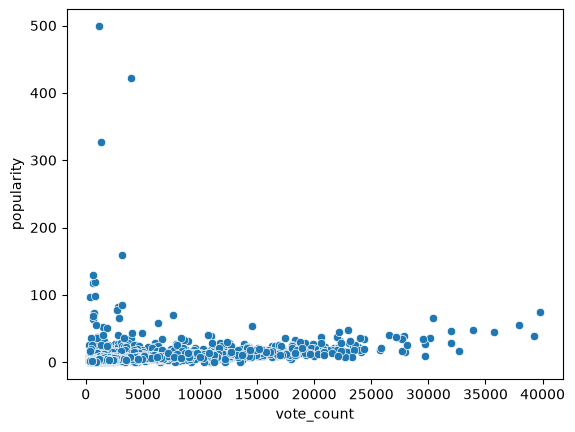

In [ ]:
sns.scatterplot(data=movies_filtrado,
                x='vote_count',
                y='popularity')

###Outliers (Valores Atípicos)
O que são Outliers? O termo significa literalmente "Valores Atípicos" ou "Pontos Fora da Curva". São dados numéricos que se distanciam drasticamente do padrão geral do conjunto de dados.

Motivação da Análise: No contexto de filmes, alguns blockbusters recebem um volume de engajamento desproporcional. Plotamos o gráfico de dispersão (scatter plot) relacionando a contagem de votos (vote_count) com a popularidade (popularity). O objetivo aqui foi identificar visualmente como esses outliers estão distribuídos. Detectar e tratar esses valores atípicos é importante, pois os modelos de Regressão Linear são muito sensíveis a extremos, e a não correção desses pontos poderia causar vieses severos na nossa reta de predição.

#### Tratando Outliers
- Transformando os dados para uma escala logarítmica

<Axes: xlabel='log_vote_count', ylabel='log_popularity'>

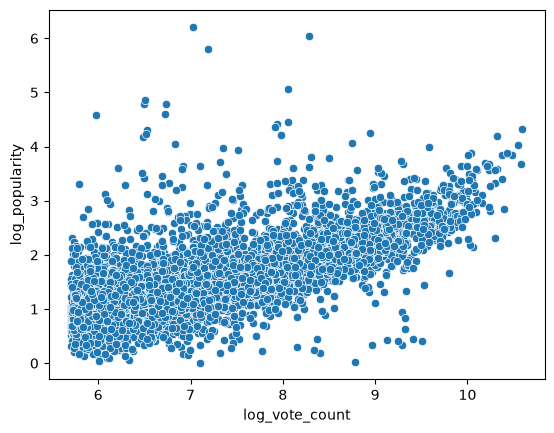

In [ ]:
movies_filtrado['log_popularity'] = np.log1p(movies_filtrado['popularity'])
movies_filtrado['log_vote_count'] = np.log1p(movies_filtrado['vote_count'])
sns.scatterplot(data=movies_filtrado,
                x='log_vote_count',
                y='log_popularity')

**Justificativa:** fizemos a conversão logarítmica para lidar com dados assimétricos. Ela atua "espremendo" os valores numericamente gigantes e "expandindo" os valores menores, o que suaviza as distorções visuais e estatísticas. Como resultado, a distribuição se aproxima muito mais de uma curva normal, normalizando a variância dos dados e permitindo que o modelo linear consiga traçar previsões com mais precisão e sem ser "puxado" pelos valores extremos.
---

# Separação dos Dados:
Optamos por separar o conjunto de dados em 80% para treinamento e 20% para teste (`test_size=0.2`). Esta proporção foi escolhida pois fornece dados suficientes para os modelos aprenderem os padrões (aproximadamente 8 mil registros) enquanto preserva uma amostra representativa (cerca de 2 mil registros) para a avaliação final, garantindo que o teste reflita o desempenho do modelo no mundo real.

In [ ]:
from sklearn.model_selection import train_test_split

# Definição das variáveis
X = movies_filtrado[['log_vote_count','vote_average','movie_age']]
y = movies_filtrado['log_popularity']

# Divisão do conjunto de dados em 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#### Aplicando Regressão Linear nos dados
- Objetivo: queremos preditar a variável 'popularity'
- Utilizamos: vote_count, vote_average e movie_age

In [ ]:
from sklearn.linear_model import LinearRegression

model_LR = LinearRegression()

model_LR.fit(X_train, y_train)

fitted_LR = model_LR.predict(X_test)

# Residuals são os erros cometidos pelo modelo a cada observação
residuals_LR = y_test-fitted_LR

#### Aplicando Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model_DT = DecisionTreeRegressor(max_depth=5)

model_DT.fit(X_train, y_train)

fitted_DT = model_DT.predict(X_test)
residuals_DT = y_test-fitted_DT

#### Aplicando Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_RF = RandomForestRegressor(max_depth=4, random_state=0)
model_RF.fit(X_train,y_train)

fitted_RF = model_RF.predict(X_test)
residuals_RF = y_test-fitted_RF

### Métricas de Avaliação de cada modelo

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mae_LR = mean_absolute_error(y_test, fitted_LR)
mse_LR = mean_squared_error(y_test, fitted_LR)
rmse_LR = np.sqrt(mse_LR)

print("======= Resultados Regressão Linear =========")
print(f"R2 Score: {r2_score(y_test, fitted_LR):.4f}")
print(f"MAE: {mae_LR:.4f}")
print(f"MSE: {mse_LR:.4f}")
print(f"RMSE: {rmse_LR:.4f}")

print("======= Resultados Decision Tree =========")
mae_DT = mean_absolute_error(y_test, fitted_DT)
mse_DT = mean_squared_error(y_test, fitted_DT)
rmse_DT = np.sqrt(mse_DT)

print(f"R2 Score: {r2_score(y_test, fitted_DT):.4f}")
print(f"MAE: {mae_DT:.4f}")
print(f"MSE: {mse_DT:.4f}")
print(f"RMSE: {rmse_DT:.4f}")

print("======== Resultados Random Forest ===========")
mae_RF = mean_absolute_error(y_test, fitted_RF)
mse_RF = mean_squared_error(y_test, fitted_RF)
rmse_RF = np.sqrt(mse_RF)

print(f"R2 Score: {r2_score(y_test, fitted_RF):.4f}")
print(f"MAE: {mae_RF:.4f}")
print(f"MSE: {mse_RF:.4f}")
print(f"RMSE: {rmse_RF:.4f}")
print("=============================================")

======= Resultados Regressão Linear =========
R2 Score: 0.5924
MAE: 0.2762
MSE: 0.1506
RMSE: 0.3880
======= Resultados Decision Tree =========
R2 Score: 0.6676
MAE: 0.2534
MSE: 0.1228
RMSE: 0.3504
======== Resultados Random Forest ===========
R2 Score: 0.6929
MAE: 0.2486
MSE: 0.1134
RMSE: 0.3368


#### Plotagem da relação dos acertos e erros Regressão Linear
- Quanto mais próximo da linha vermelha está um círculo, quer dizer que a previsão foi mais próxima do resultado real
- Quanto mais afastada, mais longe a previsão foi do resultado real

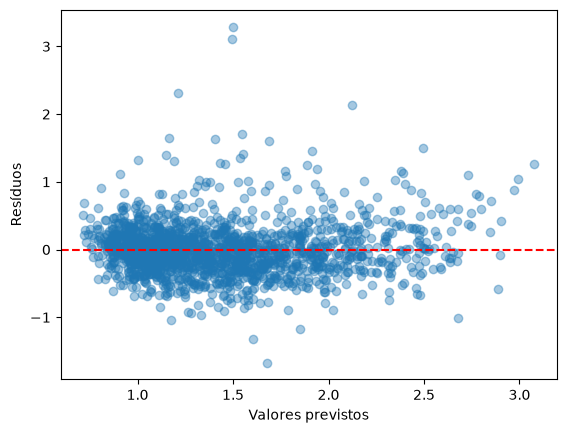

In [ ]:
plt.scatter(fitted_LR, residuals_LR, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores previstos')
plt.ylabel('Resíduos')
plt.show()

### Plotagem da relação dos acertos e erros Decision Tree

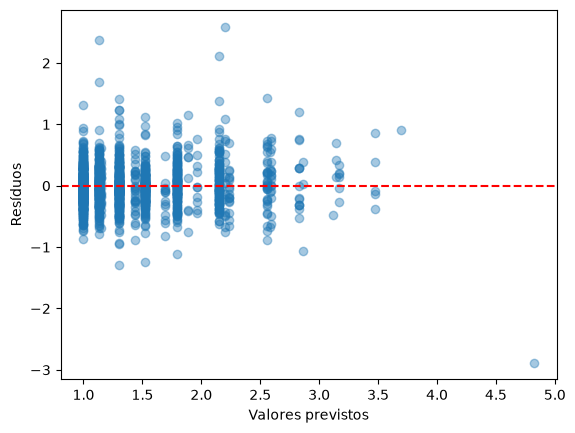

In [ ]:
plt.scatter(fitted_DT, residuals_DT, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores previstos')
plt.ylabel('Resíduos')
plt.show()

#### Plotagem da relação dos acertos e erros Random Forest
- Quanto mais próximo da linha vermelha está um círculo, quer dizer que a previsão foi mais próxima do resultado real
- Quanto mais afastada, mais longe a previsão foi do resultado real

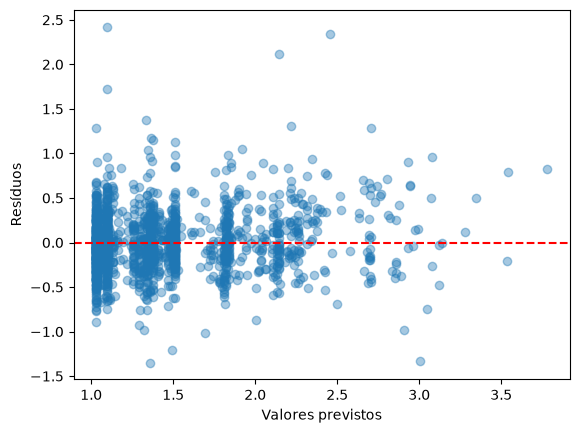

In [ ]:
plt.scatter(fitted_RF, residuals_RF, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores previstos')
plt.ylabel('Resíduos')
plt.show()

### Discussão Crítica dos Resultados

* **Comparação e Modelo Vencedor:**
  O modelo de **Random Forest** apresentou o melhor resultado, atingindo o maior R² (0.6929) e o menor erro médio (MAE: 0.2486 e RMSE: 0.3368). Ele foi escolhido como o modelo final porque a combinação de múltiplas árvores de decisão foi capaz de capturar as relações não-lineares (como a relação entre a idade do filme e sua popularidade) de forma mais eficaz que a Regressão Linear Simples, superando também facilmente o modelo Baseline.
  
* **Erros Observados:**
  Observando os gráficos de resíduos, notamos que a Regressão Linear apresenta um padrão claro de dispersão nos extremos, indicando que a relação dos dados não é perfeitamente reta. Na Random Forest, os resíduos estão mais centralizados em torno do zero (linha vermelha), mas o modelo ainda subestima a popularidade de filmes com pontuações extremamente altas (outliers residuais que o modelo não alcança).

* **Limitações:**
  A principal limitação deste projeto é a baixa quantidade de atributos preditivos utilizados (apenas três). Além disso, não utilizamos dados categóricos altamente relevantes para a popularidade de um filme, como o orçamento de marketing, o elenco, ou os gêneros da produção (Ação, Drama, etc.).

* **Melhorias Futuras:**
  Para trabalhos futuros, o desempenho pode ser ampliado realizando a codificação (One-Hot Encoding) das variáveis categóricas de idioma (`original_language`) e gênero. Além disso, técnicas de Processamento de Linguagem Natural (NLP) poderiam ser aplicadas na coluna `overview` para extrair sentimentos que prevejam se o filme tem apelo popular.